# Reach estimation with toy examples 

This allows us to see the effect of noise and sample density on the accuracy of estimates of reach.



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch

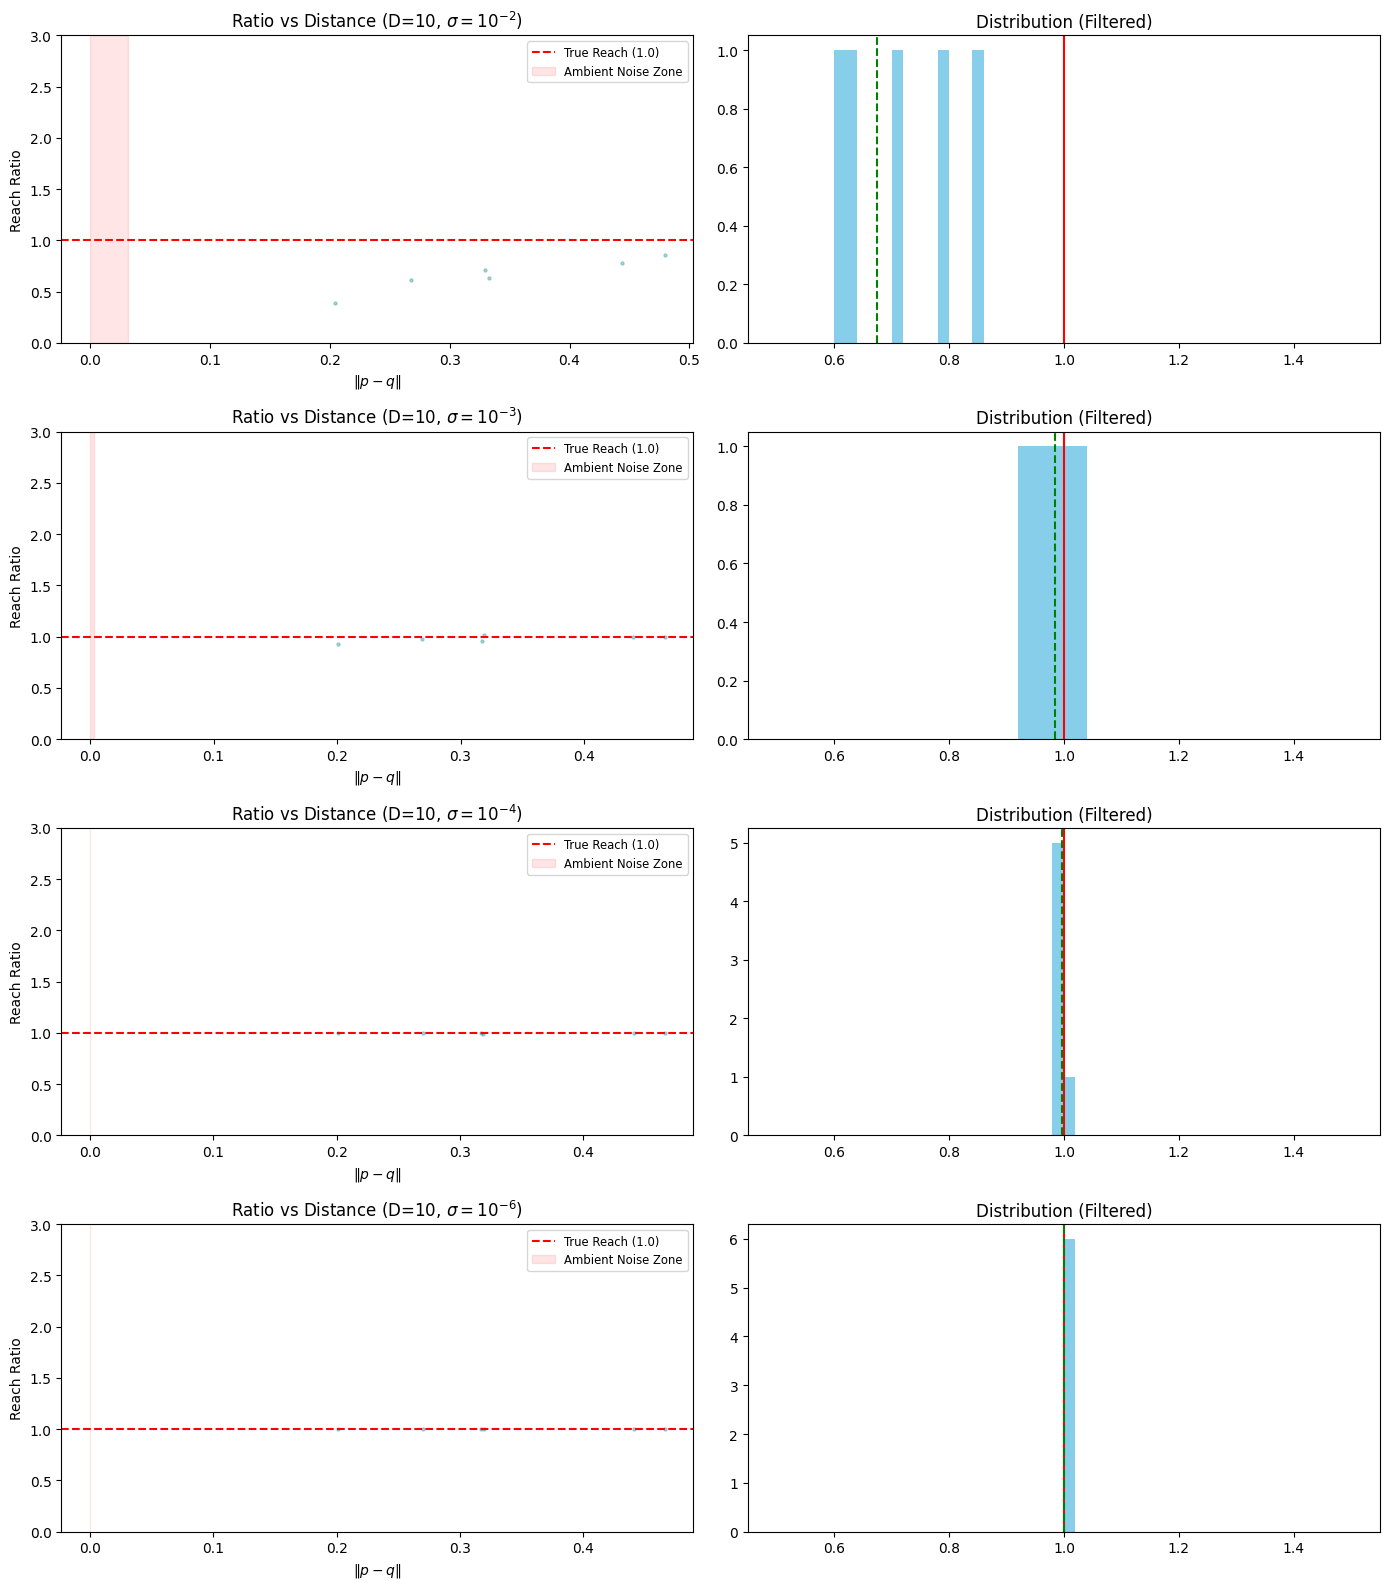

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dimensions
N_samples = 100
d_manifold = 2      # Intrinsic dimension (sphere surface)
D_ambient = 10      # Ambient dimension (e.g., 50-dimensional space)
h = 0.5             # Neighborhood radius

# 2. Generate Sphere in (d+1) and embed in D
# First, create the d-sphere points
core_points = np.random.standard_normal((N_samples, d_manifold + 1))
core_points /= np.linalg.norm(core_points, axis=1, keepdims=True)

# Create the D-dimensional ambient points (padding with zeros)
ambient_points = np.zeros((N_samples, D_ambient))
ambient_points[:, :d_manifold + 1] = core_points

# Select a fixed random point p for all plots
idx = np.random.randint(0, N_samples)
p_clean = ambient_points[idx]
# The normal vector for a sphere centered at origin is p itself
p_normal = p_clean 

# Noise levels to compare
log_sigmas = [-2, -3, -4, -6]

fig, axes = plt.subplots(len(log_sigmas), 2, figsize=(14, 4 * len(log_sigmas)))

for i, ls in enumerate(log_sigmas):
    sigma = 10**ls
    
    # 3. Add D-dimensional noise
    noise = np.random.normal(0, sigma, size=(N_samples, D_ambient))
    noisy_points = ambient_points + noise
    p_noisy = noisy_points[idx]
    
    # 4. Geometry Calculations
    diffs = noisy_points - p_noisy
    dist_sq = np.sum(diffs**2, axis=1)
    dists = np.sqrt(dist_sq)
    
    # Distance to the exact tangent plane at p
    # dist = |(q - p) dot p_normal|
    dist_to_plane = np.abs(np.dot(diffs, p_normal))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ratios = dist_sq / (2 * dist_to_plane)
    
    # Filtering
    mask = (dists > 0) & (dists < h)
    
    # Scatter Plot
    axes[i, 0].scatter(dists[mask], ratios[mask], alpha=0.3, s=5, color='teal')
    axes[i, 0].axhline(y=1.0, color='red', linestyle='--', label='True Reach (1.0)')
    axes[i, 0].axvspan(0, sigma * np.sqrt(D_ambient), color='red', alpha=0.1, label='Ambient Noise Zone')
    axes[i, 0].set_ylim(0, 3)
    axes[i, 0].set_title(rf'Ratio vs Distance (D={D_ambient}, $\sigma=10^{{{ls}}}$)')
    axes[i, 0].set_xlabel(r'$\|p - q\|$')
    axes[i, 0].set_ylabel(r'Reach Ratio')
    axes[i, 0].legend(loc='upper right', fontsize='small')
    
    # Histogram (Excluding high-noise points)
    # Note: Noise floor increases slightly with D (sqrt(D) scaling)
    noise_floor = sigma * np.sqrt(D_ambient) * 5
    clean_mask = (dists > noise_floor) & (dists < h)
    
    axes[i, 1].hist(ratios[clean_mask], bins=50, color='skyblue', range=(0.5, 1.5))
    axes[i, 1].axvline(x=1.0, color='red')
    # median line
    median_val = np.median(ratios[clean_mask])
    axes[i, 1].axvline(x=median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i, 1].set_title('Distribution (Filtered)')

plt.tight_layout()
plt.show()